In [7]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, cohen_kappa_score
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [8]:
BASE_PATH = os.getcwd()
TEST_PATH = os.path.join(BASE_PATH, "test")
MODEL_PATH = os.path.join(BASE_PATH, "weights", "EfficientNetB1_BodyParts.h5")

In [9]:
model= tf.keras.models.load_model(MODEL_PATH)

In [10]:
dataset = []

valid_ext = ('.png', '.jpg', '.jpeg')

for body_part in os.listdir(TEST_PATH):   # Elbow, Wrist, Shoulder...
    body_part_path = os.path.join(TEST_PATH, body_part)

    if not os.path.isdir(body_part_path):
        continue

    for patient in os.listdir(body_part_path):
        patient_path = os.path.join(body_part_path, patient)

        for study in os.listdir(patient_path):
            study_path = os.path.join(patient_path, study)

            for img in os.listdir(study_path):
                if img.lower().endswith(valid_ext):
                    dataset.append({
                        "Filepath": os.path.abspath(os.path.join(study_path, img)),
                        "Label": body_part   # <-- IMPORTANT CHANGE
                    })

df = pd.DataFrame(dataset)


In [11]:
datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input
)

test_images = datagen.flow_from_dataframe(
    dataframe=df,
    x_col="Filepath",
    y_col="Label",
    target_size=(224, 224),
    class_mode="categorical",
    batch_size=32,
    shuffle=False
)


Found 1482 validated image filenames belonging to 3 classes.


In [12]:
loss, accuracy = model.evaluate(test_images)
print("\nBodyParts Test Accuracy:", accuracy)

y_pred_probs = model.predict(test_images)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_images.classes

class_names = list(test_images.class_indices.keys())

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

C:\Users\lenovo\AppData\Roaming\Python\Python310\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:120: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


47/47 ━━━━━━━━━━━━━━━━━━━━ 157s 3s/step - accuracy: 0.9315 - loss: 0.6034

BodyParts Test Accuracy: 0.9338731169700623
47/47 ━━━━━━━━━━━━━━━━━━━━ 108s 2s/step

Classification Report:

              precision    recall  f1-score   support

       Elbow       0.92      0.94      0.93       463
        Hand       0.93      0.93      0.93       459
    Shoulder       0.95      0.94      0.94       560

    accuracy                           0.93      1482
   macro avg       0.93      0.93      0.93      1482
weighted avg       0.93      0.93      0.93      1482



<Figure size 600x600 with 0 Axes>

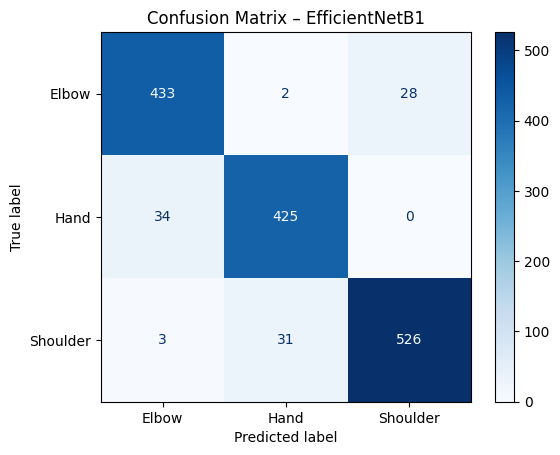

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_true, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

plt.figure(figsize=(6, 6))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix – EfficientNetB1")
plt.show()

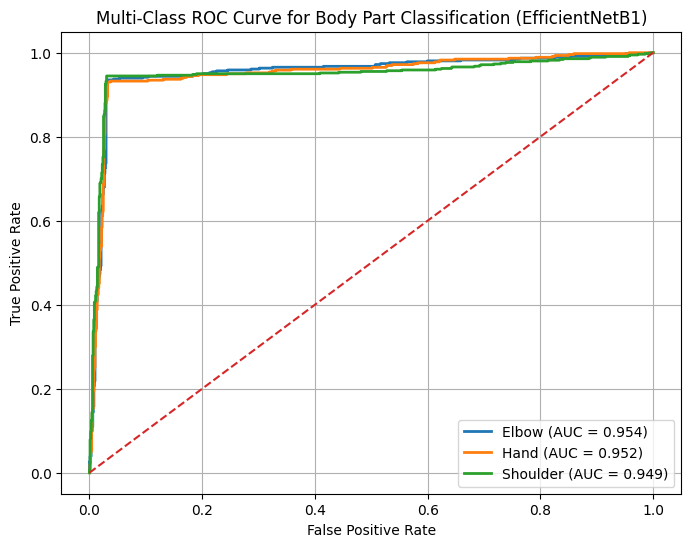


ROC-AUC Scores per Class:
Elbow: 0.954
Hand: 0.952
Shoulder: 0.949


In [14]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# number of classes
num_classes = len(class_names)

# binarize true labels
y_true_bin = label_binarize(y_true, classes=range(num_classes))

plt.figure(figsize=(8,6))

roc_auc_scores = {}

# compute ROC for each class
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    roc_auc_scores[class_names[i]] = roc_auc

    plt.plot(fpr, tpr, linewidth=2,
             label=f"{class_names[i]} (AUC = {roc_auc:.3f})")

# random classifier line
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve for Body Part Classification (EfficientNetB1)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# print AUC per class
print("\nROC-AUC Scores per Class:")
for cls, score in roc_auc_scores.items():
    print(f"{cls}: {score:.3f}")
